# The Illustrated Llama-Based Decoder &mdash; with PyTorch Code

> A step-by-step, picture-first guide to how a **Llama-based decoder** language model
> works, building every piece from scratch in **PyTorch** and running it on a tiny toy model.

This notebook is a spiritual sequel to *The Illustrated GPT-2*. GPT-2 taught the world the
**decoder-only Transformer**. Modern open models keep that same backbone but swap in four
upgrades that make training more stable and inference faster. We will build each one by hand:

| Component | GPT-2 (classic) | **Llama-based decoder (this notebook)** |
|---|---|---|
| Normalization | LayerNorm (post-norm) | **RMSNorm (pre-norm)** |
| Position info | Learned absolute embeddings | **Rotary Position Embeddings (RoPE)** |
| Attention | Multi-Head Attention | **Grouped-Query Attention (GQA)** |
| Feed-forward | GELU MLP (2 matrices) | **SwiGLU (3 matrices, gated)** |
| Linear bias | Yes | **No bias anywhere** |

By the end you will have a complete, runnable `LlamaBasedDecoder` model and you will
understand *why* each design choice exists.

<img src="./image/gpt-2-autoregression-2.gif" width="650" alt="autoregressive generation">

*Like GPT-2, a Llama-based decoder is **auto-regressive**: it generates one token at a time, feeding each prediction back in as input.*

## 0. Setup &amp; a tiny configuration

We keep everything **small** so each tensor is printable and every idea is visible.
A real model just makes these numbers bigger.

In [1]:
%matplotlib inline
import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
np.random.seed(0)
print("PyTorch:", torch.__version__)

PyTorch: 2.8.0


In [2]:
@dataclass
class ModelArgs:
    dim: int = 64            # model / embedding dimension (d_model)
    n_layers: int = 3        # number of stacked decoder blocks
    n_heads: int = 8         # number of QUERY heads
    n_kv_heads: int = 2      # number of KEY/VALUE heads  (GQA: < n_heads)
    vocab_size: int = 64     # toy vocabulary size
    multiple_of: int = 32    # round SwiGLU hidden size to a multiple of this
    norm_eps: float = 1e-5   # epsilon inside RMSNorm
    rope_theta: float = 10000.0  # base frequency for RoPE
    max_seq_len: int = 32    # longest sequence we support

args = ModelArgs()
print(args)
print("head_dim =", args.dim // args.n_heads)
print("query heads per kv head (GQA group size) =", args.n_heads // args.n_kv_heads)

ModelArgs(dim=64, n_layers=3, n_heads=8, n_kv_heads=2, vocab_size=64, multiple_of=32, norm_eps=1e-05, rope_theta=10000.0, max_seq_len=32)
head_dim = 8
query heads per kv head (GQA group size) = 4


## 1. The big picture: a stack of decoder blocks

The original Transformer had an **encoder** and a **decoder**. A Llama-based decoder
(like GPT-2 before it) throws away the encoder and just stacks **decoder blocks** as
high as compute allows.

Each block does two things, each wrapped in a **residual connection**:

1. **Self-attention** &mdash; mix information *across* tokens (so each token can look at the ones before it).
2. **Feed-forward network** &mdash; process each token *independently*.

<img src="./image/transformer-decoder-block-2.png" width="430" alt="decoder block">

The data flow we will build:

```
tokens
  -> token embeddings
  -> [ RMSNorm -> Attention(+RoPE, GQA) -> add ] x N
     [ RMSNorm -> SwiGLU FeedForward    -> add ] x N
  -> final RMSNorm
  -> output projection -> logits over vocabulary
```

> **Key difference from GPT-2 #1: pre-norm.** GPT-2 (originally) normalized *after* each
> sub-layer. Llama-based decoders normalize the *input* of each sub-layer (`x -> Norm -> SubLayer -> +x`).
> Pre-norm keeps the residual stream clean and makes very deep stacks train without exploding.

## 2. Token embeddings

The model never sees text &mdash; it sees integer **token ids**. The first layer is a lookup
table that maps each id to a learnable vector of size `dim`.

<img src="./image/gpt2-input-embedding-positional-encoding-3.png" width="600" alt="embeddings">

> **Key difference from GPT-2 #2:** GPT-2 *adds* a learned **positional** embedding here.
> A Llama-based decoder adds **nothing** about position at this stage &mdash; position is
> injected later, inside attention, by **RoPE** (Section 4). So the embedding step is just a
> pure content lookup.

In [3]:
tok_embeddings = nn.Embedding(args.vocab_size, args.dim)

# A toy "sentence": a batch of 1 sequence with 5 token ids.
tokens = torch.tensor([[7, 3, 42, 15, 1]])
print("token ids        :", tokens, "shape", tuple(tokens.shape))

h = tok_embeddings(tokens)
print("embedded vectors : shape", tuple(h.shape), "= (batch, seq_len, dim)")
print("first token vector (first 8 dims):")
print(h[0, 0, :8])

token ids        : tensor([[ 7,  3, 42, 15,  1]]) shape (1, 5)
embedded vectors : shape (1, 5, 64) = (batch, seq_len, dim)
first token vector (first 8 dims):
tensor([-1.1991, -0.0257,  1.8024, -1.0597,  3.4028, -0.5687, -0.4755,  1.7432],
       grad_fn=<SliceBackward0>)


## 3. RMSNorm &mdash; the normalization upgrade

Normalization keeps activations at a sensible scale so gradients stay healthy.

**LayerNorm** (GPT-2) re-centers *and* re-scales each vector:

$$\text{LayerNorm}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta$$

**RMSNorm** (Llama-based decoder) drops the mean-centering and the bias &mdash; it only
divides by the root-mean-square of the vector:

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d}\sum_i x_i^2 + \epsilon}} \cdot \gamma$$

Why? Computing the mean and a bias turns out to be unnecessary for stable training. RMSNorm
is **cheaper** (fewer reductions, no `beta`) yet works just as well &mdash; a recurring theme
in this architecture: *remove what you do not need*.

In [4]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))   # the learnable gain (gamma)

    def _norm(self, x):
        # divide by root-mean-square over the last (feature) dimension
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        # compute in float32 for numerical stability, then cast back
        return self._norm(x.float()).type_as(x) * self.weight


rms = RMSNorm(args.dim)
out = rms(h)
print("input  RMS (per token):", h.pow(2).mean(-1).sqrt()[0].detach())
print("output RMS (per token):", out.pow(2).mean(-1).sqrt()[0].detach(), "<- normalized to ~1")

input  RMS (per token): tensor([1.1745, 0.8566, 1.0127, 0.9273, 1.0341])
output RMS (per token): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000]) <- normalized to ~1


### Visual: LayerNorm vs RMSNorm on the same vector

Watch what each operation does to a raw vector. LayerNorm first shifts it so the mean is 0
(re-centering), then scales. RMSNorm skips the shift and only rescales &mdash; the shape of the
vector is preserved, just resized.

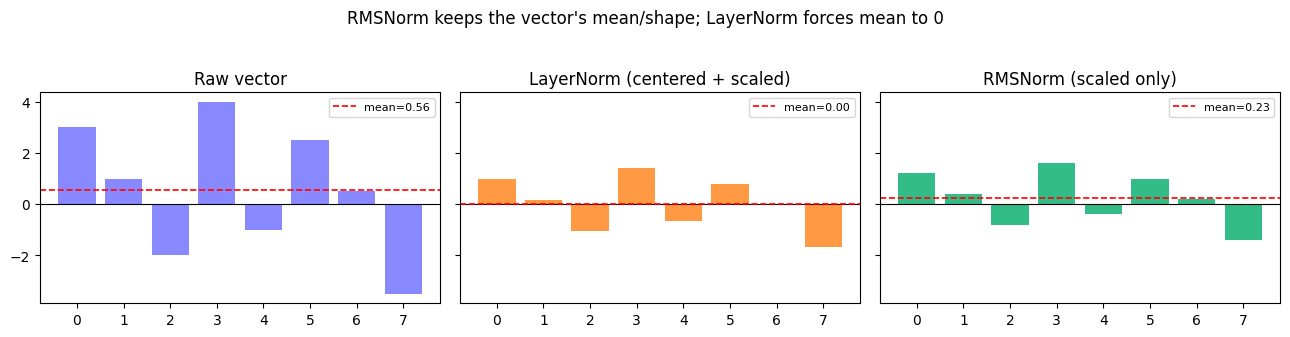

In [5]:
x = torch.tensor([3.0, 1.0, -2.0, 4.0, -1.0, 2.5, 0.5, -3.5])

ln = (x - x.mean()) / torch.sqrt(x.var(unbiased=False) + 1e-5)
rn = x * torch.rsqrt(x.pow(2).mean() + 1e-5)

idx = np.arange(len(x))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, (vals, title, color) in zip(axes, [
    (x, "Raw vector", "#8888ff"),
    (ln, "LayerNorm (centered + scaled)", "#ff9944"),
    (rn, "RMSNorm (scaled only)", "#33bb88"),
]):
    ax.bar(idx, vals.numpy(), color=color)
    ax.axhline(0, color="k", lw=0.8)
    ax.axhline(float(vals.mean()), color="red", ls="--", lw=1.2, label=f"mean={float(vals.mean()):.2f}")
    ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle("RMSNorm keeps the vector's mean/shape; LayerNorm forces mean to 0", y=1.04)
plt.tight_layout(); plt.show()

## 4. Rotary Position Embeddings (RoPE)

A pure attention mechanism is **permutation-invariant**: shuffle the tokens and it cannot
tell. We must inject *position*. GPT-2 adds a learned position vector to each embedding.
A Llama-based decoder instead **rotates** the query and key vectors by an angle that depends
on their position.

### The idea
Split each head's vector into pairs of numbers and treat every pair as a 2D point. For a token
at position $m$, rotate pair $i$ by angle $m \cdot \theta_i$:

$$\begin{pmatrix} x'_{2i} \\ x'_{2i+1}\end{pmatrix} =
\begin{pmatrix} \cos m\theta_i & -\sin m\theta_i \\ \sin m\theta_i & \cos m\theta_i \end{pmatrix}
\begin{pmatrix} x_{2i} \\ x_{2i+1}\end{pmatrix},
\qquad \theta_i = \text{base}^{-2i/d}$$

The magic: when attention computes a dot product between a query at position $m$ and a key at
position $n$, the rotations combine into a function of $(m-n)$ &mdash; the **relative**
distance. The model gets relative-position awareness for free, and it extrapolates to longer
sequences far better than learned absolute embeddings.

Different pairs rotate at different speeds (`theta_i`): low dimensions spin fast (capture local
order), high dimensions spin slowly (capture long-range order).

In [6]:
def precompute_freqs_cis(head_dim: int, seq_len: int, theta: float = 10000.0):
    """Precompute the complex rotation factors e^{i * m * theta_i} for every position m."""
    # one frequency per pair of dims:  theta_i = base^(-2i/d)
    freqs = 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    t = torch.arange(seq_len)                 # positions 0..seq_len-1
    freqs = torch.outer(t, freqs)             # (seq_len, head_dim/2) -> angle for each (pos, pair)
    # turn each angle into a unit complex number  cos(angle) + i*sin(angle)
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)
    return freqs_cis


head_dim = args.dim // args.n_heads
freqs_cis = precompute_freqs_cis(head_dim, args.max_seq_len, args.rope_theta)
print("freqs_cis shape:", tuple(freqs_cis.shape), "= (seq_len, head_dim/2), complex")
print("angle for (position=3, pair=0):", torch.angle(freqs_cis[3, 0]).item())

freqs_cis shape: (32, 4) = (seq_len, head_dim/2), complex
angle for (position=3, pair=0): 3.0


In [7]:
def reshape_for_broadcast(freqs_cis, x):
    """Reshape (T, head_dim/2) so it broadcasts over (B, T, H, head_dim/2)."""
    ndim = x.ndim
    shape = [d if i == 1 or i == ndim - 1 else 1 for i, d in enumerate(x.shape)]
    return freqs_cis.view(*shape)


def apply_rotary_emb(xq, xk, freqs_cis):
    """Rotate query and key vectors. xq/xk: (B, T, n_heads, head_dim)."""
    # view the last dim as (head_dim/2) complex numbers: pair (x0,x1) -> x0 + i*x1
    xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_ = torch.view_as_complex(xk.float().reshape(*xk.shape[:-1], -1, 2))
    fc = reshape_for_broadcast(freqs_cis, xq_)
    # complex multiply == 2D rotation
    xq_out = torch.view_as_real(xq_ * fc).flatten(3)
    xk_out = torch.view_as_real(xk_ * fc).flatten(3)
    return xq_out.type_as(xq), xk_out.type_as(xk)


# demo on random q/k
B, T, H = 1, 5, args.n_heads
q = torch.randn(B, T, H, head_dim)
k = torch.randn(B, T, H, head_dim)
qr, kr = apply_rotary_emb(q, k, freqs_cis[:T])
print("rotation preserves vector length (rotation is norm-preserving):")
print("  before:", q[0, :, 0].norm(dim=-1).detach())
print("  after :", qr[0, :, 0].norm(dim=-1).detach())

rotation preserves vector length (rotation is norm-preserving):
  before: tensor([2.8843, 1.9845, 3.2636, 2.6333, 2.8833])
  after : tensor([2.8843, 1.9845, 3.2636, 2.6333, 2.8833])


### Visual 1: every position is a rotation of the same vector

Here is a single 2D pair of one query vector, shown at positions 0..7. RoPE simply spins it
around the circle &mdash; the *length* never changes, only the *angle*, and the angle encodes
*where* the token is.

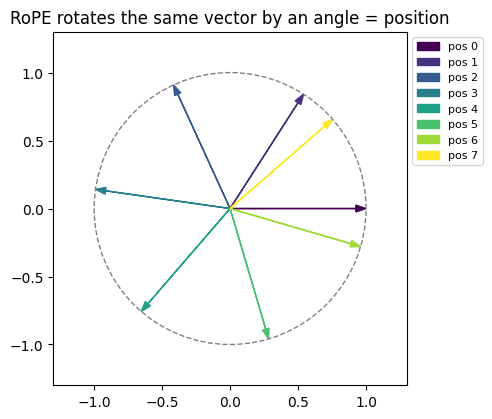

In [8]:
base_vec = torch.tensor([1.0, 0.0])
fig, ax = plt.subplots(figsize=(5, 5))
colors = plt.cm.viridis(np.linspace(0, 1, 8))
for pos in range(8):
    angle = pos * (1.0 / (10000.0 ** 0))      # fastest-spinning pair (theta_0 = 1)
    rot = torch.tensor([[math.cos(angle), -math.sin(angle)],
                        [math.sin(angle),  math.cos(angle)]])
    v = rot @ base_vec
    ax.arrow(0, 0, float(v[0]), float(v[1]), head_width=0.05, color=colors[pos],
             length_includes_head=True, label=f"pos {pos}")
circle = plt.Circle((0, 0), 1.0, fill=False, ls="--", color="gray")
ax.add_patch(circle)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), fontsize=8)
ax.set_title("RoPE rotates the same vector by an angle = position")
plt.tight_layout(); plt.show()

### Visual 2: fast and slow frequencies

Each row below is one feature-pair; each column is a position. Low pairs (top) oscillate
quickly &mdash; great for fine-grained local order. High pairs (bottom) barely move across the
whole sequence &mdash; great for coarse long-range position.

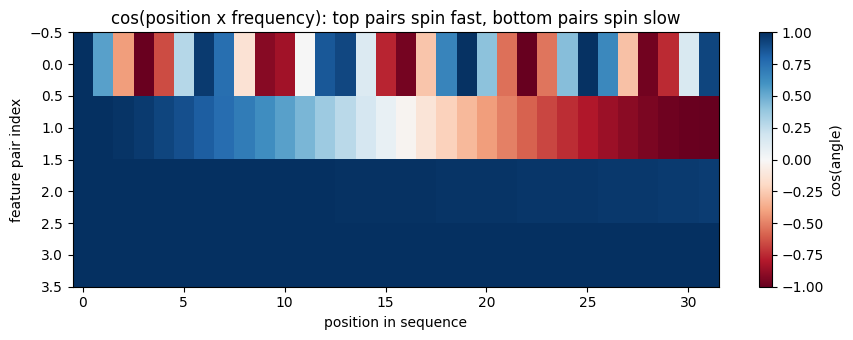

In [9]:
angles = torch.angle(freqs_cis)            # (seq_len, head_dim/2)
fig, ax = plt.subplots(figsize=(9, 3.5))
im = ax.imshow(torch.cos(angles).T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("position in sequence"); ax.set_ylabel("feature pair index")
ax.set_title("cos(position x frequency): top pairs spin fast, bottom pairs spin slow")
plt.colorbar(im, label="cos(angle)"); plt.tight_layout(); plt.show()

### Visual 3: attention "sees" relative distance

Take one query and one key with identical content. Slide them apart and measure their RoPE dot
product. The score depends only on **how far apart** they are &mdash; not on absolute position.
That is the property that makes RoPE generalize.

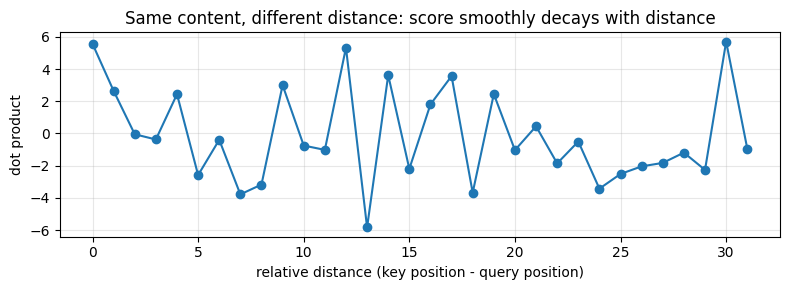

In [10]:
qv = torch.randn(1, args.max_seq_len, 1, head_dim)
kv = qv.clone()                                  # same content at every position
qrot, krot = apply_rotary_emb(qv, kv, freqs_cis)
# dot product between query at position 0 and key at every position n
scores = (qrot[0, 0, 0] * krot[0, :, 0]).sum(-1)
plt.figure(figsize=(8, 3))
plt.plot(scores.detach().numpy(), marker="o")
plt.xlabel("relative distance (key position - query position)")
plt.ylabel("dot product")
plt.title("Same content, different distance: score smoothly decays with distance")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Self-attention: a 60-second recap

Attention lets each token gather information from other tokens. Every token produces three
vectors:

- **Query** &mdash; what *I* am looking for.
- **Key** &mdash; what *I* contain (an advert for myself).
- **Value** &mdash; the information *I* will hand over if chosen.

<img src="./image/self-attention-example-folders-3.png" width="600" alt="qkv folders analogy">

Each query is compared (dot product) against every key to produce **scores**, the scores become
weights via softmax, and the output is the weighted sum of values.

<img src="./image/self-attention-summary.png" width="600" alt="self attention summary">

### Masked (causal) self-attention

A language model must not peek at the future. So before softmax we **mask** every position to
the right of the current token by setting its score to $-\infty$.

<img src="./image/transformer-attention-mask.png" width="560" alt="attention mask">

After softmax those masked cells become exactly 0 &mdash; the token can only attend to itself
and the past.

<img src="./image/transformer-attention-masked-scores-softmax.png" width="560" alt="masked softmax">

In [11]:
def causal_mask(seq_len):
    # upper-triangular matrix of -inf above the diagonal, 0 elsewhere
    mask = torch.full((seq_len, seq_len), float("-inf"))
    return torch.triu(mask, diagonal=1)


m = causal_mask(5)
print("causal mask (0 = visible, -inf = blocked):")
print(m)

causal mask (0 = visible, -inf = blocked):
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


### Scaled dot-product attention

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + \text{mask}\right)V$$

We divide by $\sqrt{d_k}$ so the scores do not blow up for large head dimensions (which would
push softmax into tiny-gradient regions).

In [12]:
def scaled_dot_product_attention(q, k, v, mask=None):
    # q,k,v: (B, n_heads, T, head_dim)
    d_k = q.shape[-1]
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_k)   # (B, H, T, T)
    if mask is not None:
        scores = scores + mask
    weights = F.softmax(scores.float(), dim=-1).type_as(q)
    out = weights @ v
    return out, weights


# quick sanity check on random tensors
qd = torch.randn(1, 2, 5, head_dim)
od, wd = scaled_dot_product_attention(qd, qd, qd, causal_mask(5))
print("attention weights for head 0 (rows = query, cols = key):")
print(wd[0, 0].detach().round(decimals=2))
print("each row sums to 1 and is lower-triangular (no future leakage)")

attention weights for head 0 (rows = query, cols = key):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1300, 0.8700, 0.0000, 0.0000, 0.0000],
        [0.0300, 0.0000, 0.9600, 0.0000, 0.0000],
        [0.0100, 0.0100, 0.0500, 0.9400, 0.0000],
        [0.0800, 0.1200, 0.1300, 0.1900, 0.4800]])
each row sums to 1 and is lower-triangular (no future leakage)


## 6. Grouped-Query Attention (GQA)

In classic **Multi-Head Attention (MHA)** every query head has its *own* key and value head.
During generation we cache all those keys and values (the **KV cache**) &mdash; and that cache
is what eats memory and bandwidth at inference time.

> **Key difference from GPT-2 #3.** A Llama-based decoder uses **Grouped-Query Attention**:
> many query heads **share** a smaller number of key/value heads. This shrinks the KV cache
> (here by 4&times;: 8 query heads but only 2 KV heads) with almost no quality loss.

Two extremes and the middle ground:

- **MHA**: `n_kv_heads == n_heads` (one KV per query). Best quality, biggest cache.
- **MQA**: `n_kv_heads == 1` (all queries share one KV). Smallest cache, some quality loss.
- **GQA**: `1 < n_kv_heads < n_heads`. The sweet spot used by Llama-based decoders.

<img src="./image/gpt2-self-attention-split-attention-heads-2.png" width="600" alt="attention heads">

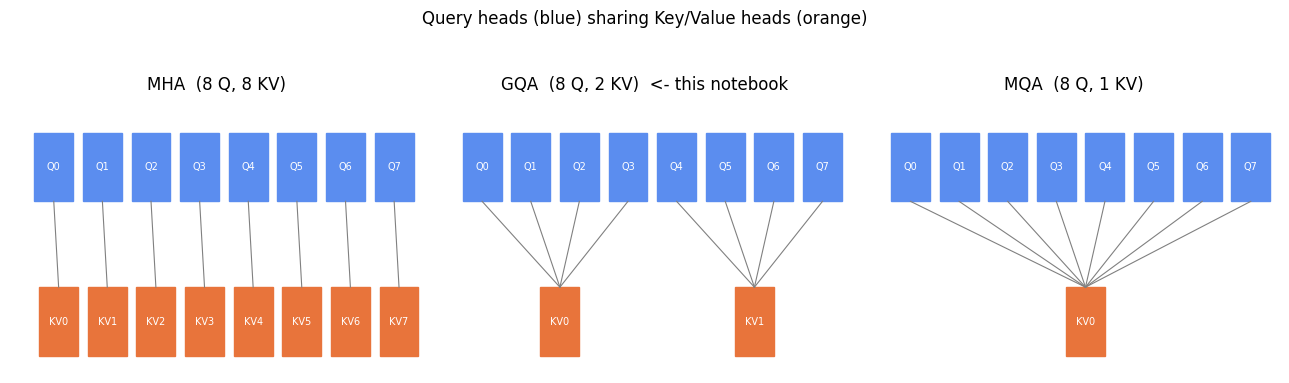

In [13]:
# A schematic of MHA vs GQA vs MQA
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

def draw(ax, n_q, n_kv, title):
    group = n_q // n_kv
    for qi in range(n_q):
        kv = qi // group
        ax.add_patch(plt.Rectangle((qi, 2), 0.8, 0.8, color="#5b8def"))
        ax.text(qi + 0.4, 2.4, f"Q{qi}", ha="center", va="center", color="white", fontsize=7)
        ax.plot([qi + 0.4, kv * group + group/2], [2, 1], color="gray", lw=0.8)
    for ki in range(n_kv):
        ax.add_patch(plt.Rectangle((ki * group + group/2 - 0.4, 0.2), 0.8, 0.8, color="#e8743b"))
        ax.text(ki * group + group/2, 0.6, f"KV{ki}", ha="center", va="center", color="white", fontsize=7)
    ax.set_xlim(-0.5, n_q); ax.set_ylim(0, 3.2); ax.axis("off"); ax.set_title(title)

draw(axes[0], 8, 8, "MHA  (8 Q, 8 KV)")
draw(axes[1], 8, 2, "GQA  (8 Q, 2 KV)  <- this notebook")
draw(axes[2], 8, 1, "MQA  (8 Q, 1 KV)")
plt.suptitle("Query heads (blue) sharing Key/Value heads (orange)", y=1.05)
plt.tight_layout(); plt.show()

In [14]:
def repeat_kv(x, n_rep: int):
    """Expand KV heads so each group of query heads has a matching KV head.
    x: (B, T, n_kv_heads, head_dim) -> (B, T, n_kv_heads * n_rep, head_dim)"""
    B, T, n_kv, hd = x.shape
    if n_rep == 1:
        return x
    return (
        x[:, :, :, None, :]
        .expand(B, T, n_kv, n_rep, hd)
        .reshape(B, T, n_kv * n_rep, hd)
    )


kv_demo = torch.randn(1, 5, args.n_kv_heads, head_dim)
print("kv heads before repeat:", tuple(kv_demo.shape))
print("kv heads after  repeat:", tuple(repeat_kv(kv_demo, args.n_heads // args.n_kv_heads).shape))

kv heads before repeat: (1, 5, 2, 8)
kv heads after  repeat: (1, 5, 8, 8)


### The full attention module

This puts everything together: project to Q/K/V (no bias), apply **RoPE** to Q and K,
**repeat** the KV heads for GQA, run masked scaled-dot-product attention, then project back.

In [15]:
class Attention(nn.Module):
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.n_heads = args.n_heads
        self.n_kv_heads = args.n_kv_heads
        self.n_rep = args.n_heads // args.n_kv_heads
        self.head_dim = args.dim // args.n_heads

        # note: bias=False everywhere (key difference #4)
        self.wq = nn.Linear(args.dim, args.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(args.dim, args.n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(args.dim, args.n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(args.n_heads * self.head_dim, args.dim, bias=False)

    def forward(self, x, freqs_cis, mask):
        B, T, _ = x.shape

        xq = self.wq(x).view(B, T, self.n_heads, self.head_dim)
        xk = self.wk(x).view(B, T, self.n_kv_heads, self.head_dim)
        xv = self.wv(x).view(B, T, self.n_kv_heads, self.head_dim)

        # inject position by rotating queries and keys
        xq, xk = apply_rotary_emb(xq, xk, freqs_cis)

        # GQA: replicate the few KV heads up to the number of query heads
        xk = repeat_kv(xk, self.n_rep)
        xv = repeat_kv(xv, self.n_rep)

        # (B, T, H, hd) -> (B, H, T, hd)
        xq, xk, xv = (t.transpose(1, 2) for t in (xq, xk, xv))

        out, weights = scaled_dot_product_attention(xq, xk, xv, mask)

        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.wo(out), weights


attn = Attention(args)
y, w = attn(h, freqs_cis[:tokens.shape[1]], causal_mask(tokens.shape[1]))
print("attention output shape:", tuple(y.shape))
print("attention weights shape:", tuple(w.shape), "= (batch, n_heads, T, T)")

attention output shape: (1, 5, 64)
attention weights shape: (1, 8, 5, 5) = (batch, n_heads, T, T)


## 7. SwiGLU feed-forward network

After attention mixes tokens, the feed-forward network processes each token on its own.
GPT-2 uses a simple 2-matrix MLP with GELU. A Llama-based decoder uses **SwiGLU**, a *gated*
network with **three** matrices:

$$\text{SwiGLU}(x) = W_2\big(\underbrace{\text{SiLU}(W_1 x)}_{\text{gate}} \odot \underbrace{W_3 x}_{\text{value}}\big)$$

<img src="./image/gpt2-mlp1.gif" width="600" alt="feed forward">

- `W1` produces a **gate**, passed through **SiLU** ($x\cdot\sigma(x)$, a smooth ReLU).
- `W3` produces a **value** projection.
- The two are multiplied **element-wise** &mdash; the gate decides how much of each value passes.
- `W2` projects back down to `dim`.

Because there are three matrices instead of two, the hidden size is shrunk to $\tfrac{2}{3}$
(and rounded to a hardware-friendly multiple) so the total parameter count stays comparable.

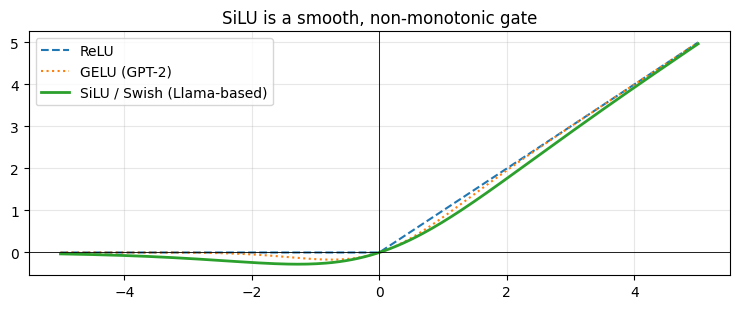

In [16]:
# SiLU vs ReLU vs GELU
xs = torch.linspace(-5, 5, 200)
plt.figure(figsize=(7.5, 3.2))
plt.plot(xs, F.relu(xs), label="ReLU", ls="--")
plt.plot(xs, F.gelu(xs), label="GELU (GPT-2)", ls=":")
plt.plot(xs, F.silu(xs), label="SiLU / Swish (Llama-based)", lw=2)
plt.axhline(0, color="k", lw=0.6); plt.axvline(0, color="k", lw=0.6)
plt.legend(); plt.title("SiLU is a smooth, non-monotonic gate"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, multiple_of):
        super().__init__()
        # shrink to 2/3 (three matrices) then round up to a multiple
        hidden_dim = int(2 * hidden_dim / 3)
        hidden_dim = multiple_of * ((hidden_dim + multiple_of - 1) // multiple_of)

        self.w1 = nn.Linear(dim, hidden_dim, bias=False)   # gate
        self.w3 = nn.Linear(dim, hidden_dim, bias=False)   # value (up-projection)
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)   # down-projection

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


ff = FeedForward(args.dim, 4 * args.dim, args.multiple_of)
print("SwiGLU hidden dim:", ff.w1.out_features)
print("feed-forward output shape:", tuple(ff(h).shape))

SwiGLU hidden dim: 192
feed-forward output shape: (1, 5, 64)


## 8. The decoder block

Now assemble one block. Note the **pre-norm residual** pattern &mdash; we normalize the input to
each sub-layer and add the sub-layer's output back onto the untouched residual stream:

```
h = x + Attention(RMSNorm(x))
out = h + FeedForward(RMSNorm(h))
```

<img src="./image/transformer-decoder-block-2.png" width="430" alt="decoder block">

In [18]:
class TransformerBlock(nn.Module):
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.attention = Attention(args)
        self.feed_forward = FeedForward(args.dim, 4 * args.dim, args.multiple_of)
        self.attention_norm = RMSNorm(args.dim, args.norm_eps)   # pre-norm for attention
        self.ffn_norm = RMSNorm(args.dim, args.norm_eps)         # pre-norm for FFN

    def forward(self, x, freqs_cis, mask):
        attn_out, weights = self.attention(self.attention_norm(x), freqs_cis, mask)
        h = x + attn_out                                  # residual add
        out = h + self.feed_forward(self.ffn_norm(h))     # residual add
        return out, weights


block = TransformerBlock(args)
y, _ = block(h, freqs_cis[:tokens.shape[1]], causal_mask(tokens.shape[1]))
print("block output shape:", tuple(y.shape), "(same as input -> blocks are stackable)")

block output shape: (1, 5, 64) (same as input -> blocks are stackable)


## 9. The full Llama-based decoder

Stack `n_layers` blocks, finish with a final RMSNorm, then project to vocabulary-size
**logits**. Position factors (`freqs_cis`) are precomputed once and the causal mask is built
per forward pass.

<img src="./image/gpt2-weights-2.png" width="600" alt="full model weights">

In [19]:
class LlamaBasedDecoder(nn.Module):
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.args = args
        self.tok_embeddings = nn.Embedding(args.vocab_size, args.dim)
        self.layers = nn.ModuleList([TransformerBlock(args) for _ in range(args.n_layers)])
        self.norm = RMSNorm(args.dim, args.norm_eps)
        self.output = nn.Linear(args.dim, args.vocab_size, bias=False)

        # precompute RoPE factors once (extra length so we can extrapolate a bit)
        self.register_buffer(
            "freqs_cis",
            precompute_freqs_cis(args.dim // args.n_heads, args.max_seq_len * 2, args.rope_theta),
            persistent=False,
        )

    def forward(self, tokens, return_attn=False):
        B, T = tokens.shape
        h = self.tok_embeddings(tokens)
        freqs_cis = self.freqs_cis[:T].to(h.device)
        mask = causal_mask(T).to(h.device) if T > 1 else None

        attns = []
        for layer in self.layers:
            h, w = layer(h, freqs_cis, mask)
            if return_attn:
                attns.append(w)

        h = self.norm(h)
        logits = self.output(h)
        return (logits, attns) if return_attn else logits


model = LlamaBasedDecoder(args)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\\nTotal parameters: {n_params:,}")

LlamaBasedDecoder(
  (tok_embeddings): Embedding(64, 64)
  (layers): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attention): Attention(
        (wq): Linear(in_features=64, out_features=64, bias=False)
        (wk): Linear(in_features=64, out_features=16, bias=False)
        (wv): Linear(in_features=64, out_features=16, bias=False)
        (wo): Linear(in_features=64, out_features=64, bias=False)
      )
      (feed_forward): FeedForward(
        (w1): Linear(in_features=64, out_features=192, bias=False)
        (w3): Linear(in_features=64, out_features=192, bias=False)
        (w2): Linear(in_features=192, out_features=64, bias=False)
      )
      (attention_norm): RMSNorm()
      (ffn_norm): RMSNorm()
    )
  )
  (norm): RMSNorm()
  (output): Linear(in_features=64, out_features=64, bias=False)
)
\nTotal parameters: 149,952


In [20]:
logits, attns = model(tokens, return_attn=True)
print("input tokens :", tokens.tolist())
print("logits shape :", tuple(logits.shape), "= (batch, seq_len, vocab_size)")
print("the model's next-token prediction at each position (argmax, untrained = random):")
print(logits.argmax(-1).tolist())

input tokens : [[7, 3, 42, 15, 1]]
logits shape : (1, 5, 64) = (batch, seq_len, vocab_size)
the model's next-token prediction at each position (argmax, untrained = random):
[[16, 49, 41, 36, 47]]


### Peeking inside: a real attention map

Because of the causal mask every attention map is **lower-triangular** &mdash; each token
(row) only distributes weight over itself and earlier tokens (columns).

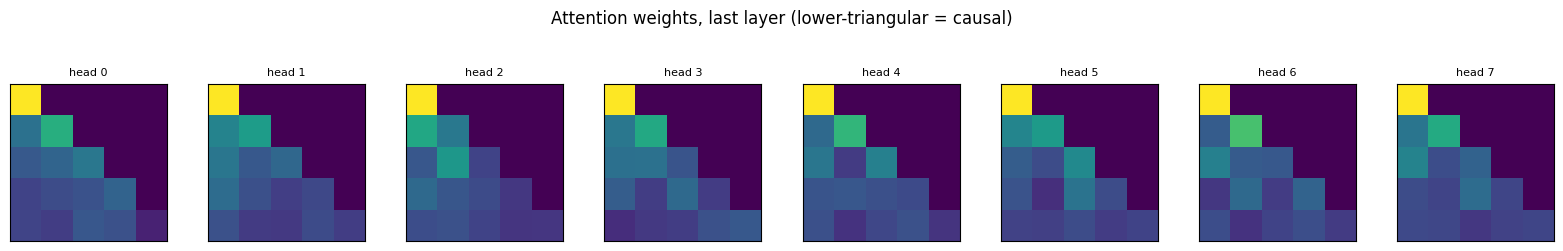

In [21]:
fig, axes = plt.subplots(1, args.n_heads, figsize=(2.0 * args.n_heads, 2.2))
last_layer = attns[-1][0]   # (n_heads, T, T) for the first sequence in the batch
for hd in range(args.n_heads):
    ax = axes[hd]
    ax.imshow(last_layer[hd].detach(), cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"head {hd}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Attention weights, last layer (lower-triangular = causal)", y=1.12)
plt.tight_layout(); plt.show()

## 10. Auto-regressive generation

To generate text the model predicts the next token, appends it to the input, and repeats.
This loop is what makes it a *language model*.

<img src="./image/gpt-2-output.gif" width="650" alt="autoregressive output">

> **Note on speed.** For clarity this loop re-runs the whole sequence each step. Production
> Llama-based decoders keep a **KV cache** &mdash; storing the already-computed keys/values so
> each new step only processes the single new token. GQA (Section 6) is exactly what keeps that
> cache small.

In [22]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.args.max_seq_len:]      # never exceed context window
        logits = model(idx_cond)
        logits = logits[:, -1, :] / temperature          # focus on the last position
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = -float("inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)           # append and continue
    return idx


prompt = torch.tensor([[7, 3, 42]])
generated = generate(model, prompt, max_new_tokens=10, temperature=0.8, top_k=20)
print("prompt   :", prompt.tolist())
print("generated:", generated.tolist())
print("(untrained model -> ids look random, but the machinery is real and complete)")

prompt   :

 [[7, 3, 42]]
generated: [[7, 3, 42, 9, 18, 50, 25, 37, 24, 27, 59, 27, 56]]
(untrained model -> ids look random, but the machinery is real and complete)


### Bonus: it actually learns

To prove every piece is wired correctly, let's overfit the model on one tiny sequence. If the
loss drops toward zero, gradients flow correctly through RMSNorm, RoPE, GQA and SwiGLU.

step   0  loss 4.2729
step  20  loss 0.0782
step  40  loss 0.0153
step  60  loss 0.0083


step  80  loss 0.0060
step 100  loss 0.0047


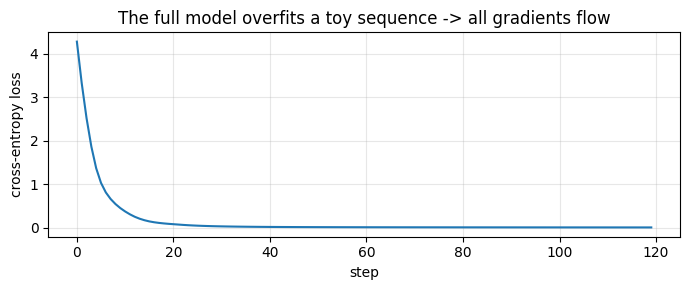

\ntarget   : [[20, 25, 54, 40, 57, 44, 57, 29, 45, 62, 25, 44, 63, 53, 23]]
predicted: [[20, 25, 54, 40, 57, 44, 57, 29, 45, 62, 25, 44, 63, 53, 23]]
match    : True


In [23]:
seq = torch.randint(0, args.vocab_size, (1, 16))
x_in, y_target = seq[:, :-1], seq[:, 1:]

model.train()
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
losses = []
for step in range(120):
    logits = model(x_in)
    loss = F.cross_entropy(logits.reshape(-1, args.vocab_size), y_target.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 20 == 0:
        print(f"step {step:3d}  loss {loss.item():.4f}")

plt.figure(figsize=(7, 3))
plt.plot(losses); plt.xlabel("step"); plt.ylabel("cross-entropy loss")
plt.title("The full model overfits a toy sequence -> all gradients flow"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

pred = model(x_in).argmax(-1)
print("\\ntarget   :", y_target.tolist())
print("predicted:", pred.tolist())
print("match    :", bool((pred == y_target).all()))

## 11. Recap

You just built a complete **Llama-based decoder** from scratch in PyTorch. The backbone is the
same decoder-only Transformer that GPT-2 introduced; the differences are four targeted
upgrades:

| Upgrade | What it replaces | Why it matters |
|---|---|---|
| **RMSNorm** (pre-norm) | LayerNorm (post-norm) | cheaper, stable training of deep stacks |
| **RoPE** | learned absolute position embeddings | relative position + better length extrapolation |
| **GQA** | full multi-head attention | much smaller KV cache -> faster, cheaper inference |
| **SwiGLU** | GELU MLP | a gated FFN that learns better per parameter |
| **no biases** | biased linear layers | fewer params, no quality loss |

The data flow, one more time:

```
tokens
  -> token embeddings
  -> [ RMSNorm -> Attention(RoPE + GQA) -> +residual ] x N
     [ RMSNorm -> SwiGLU FeedForward      -> +residual ] x N
  -> final RMSNorm
  -> output projection -> logits
  -> sample -> append -> repeat (auto-regression)
```

**Where to go next:** tie the embedding and output weights, add a real KV cache, swap in a
BPE tokenizer, and train on actual text. The architecture you have here is exactly the one that
scales to billions of parameters &mdash; only the numbers get bigger.